# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Tangaran, Grisby Paul James
- _Student No._: 2024-02777
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 2D Wave interference (Gezerlis Problem 1.15)

![Figure for the Wave Interference plot of Problem 1](wave_interference.png)

Figure 1: 2D wave interference pattern of 2 objects located at $(-1,0)$ and $(1,0)$. Coordinates and values are expressed in arbitrary units (a.u.).

The figure shows the density plot of the field $W(r)$, obtained from the superposition of the two point sources, illustrating the interference pattern between them. Because a sequential colormap is used, darker shades indicate large positive values of $W(r)$ (constructive interference at a wave crest), while lighter shades indicate values near zero (destructive interference) or strongly negative values (constructive interference at a wave trough). In particular, constructive interference appears at the origin, which is equidistant from both point sources, as reflected by its darker shading.

### Problem 2 Listcomps-maxxing

A custom matrix_multiply() function was implemented from scratch, without using external libraries such as NumPy. The algorithm was written idiomatically using nested list comprehensions rather than explicit for loops with placeholder matrices. The result matrix is built directly in a single expression by evaluating the scalar product between each row of the left matrix and each column of the right matrix (obtained via transpose_matrix). 

(i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
* The `@` operator is likely preferred for larger matrices since NumPy is built for numerical computation and is generally optimized for speed. NumPy calls into precompiled C code and takes advantage of optimizations built for numerical operations, whereas my custom `matrix_multiply()` still relies on Python loops (through the list comprehensions) to compute each value one at a time. This is likely slower than however NumPy handles it internally, especially as the matrices get bigger, due to Python loop overhead, dynamic type checking at every step, and fragmented memory usage from standard Python lists.

(ii) What are the general benefits of writing idiomatic Python?
* Writing idiomatic Python makes code more concise and readable, allowing others (and yourself) to more easily follow and debug the logic. It also tends to be more efficient, since idiomatic constructs like list comprehensions and built-in functions are optimized at the interpreter level, often running faster than equivalent manually written loops.


### Other comments
- This exercise was both fun and challenging. For Problem 1, I mainly modified the code already provided in the book, as hinted in the problem. For Problem 2, I first wrote everything using explicit for loops, since that was the approach I understood best and was most familiar with. Once I had working versions, I went back and rewrote them more idiomatically, applying what I learned from the lecture and textbook. This helped me better appreciate idiomatic Python (list comprehensions, zip, etc.) as it made the code more compact.


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

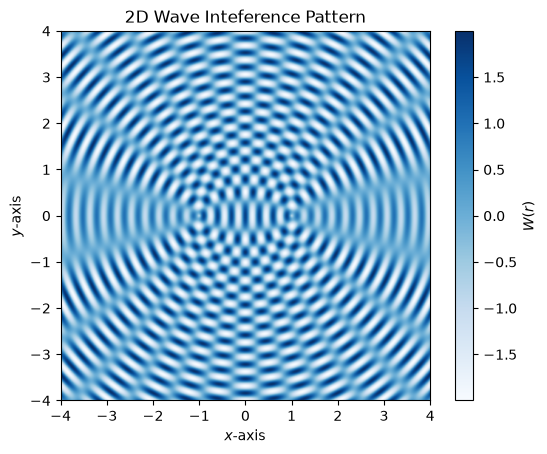

In [29]:
import matplotlib.pyplot as plt
import math 

#constants
A = 1
k = (2*math.pi)/0.3

#modeling the water basin
def makebasin(xs, ys):
    r = [(-1, 0), (1,0)] # coordinates of the two wave sources (droplets). can add more coordinates for more droplets
    n = len(xs)
    Wr = [[0. for i in range(n)] for j in range(n)] #creates an empty matrix where we will put W(r)
    # loops through all the elements of the matrix
    for i, x in enumerate(xs):  
        for j, y in enumerate(ys):  
            for rx, ry in r:
                R = math.sqrt((x-rx)**2 + (y-ry)**2) #distance formula
                Wr[j][i] += A*math.sin(k*R) #W(r) formula
    return Wr

#creates the plot
def plotfield(box, n): 
    
    # Generate a list of n evenly spaced x-points spanning -box to +box to compute W(r)
    xs = [-box + i*2*box/(n-1) for i in range(n)] 
    ys = xs[:]
    Wr = makebasin(xs, ys)

    plt.title('2D Wave Inteference Pattern')
    plt.imshow(Wr, extent=(-box, box, -box, box), cmap='Blues') #boundaries and color of the plot
    plt.colorbar(label='$W(r)$')
    plt.xlabel('$x$-axis')
    plt.ylabel('$y$-axis')
    plt.savefig('wave_interference.png') #saves the image 
    plt.show()

plotfield(4, 500)

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

* The following code generates a density plot to visualize 2D wave interference produced by two droplets acting as point sources. At each spatial coordinate within the plot's bounds, the combined effect of both droplets is computed by summing their individual wave contributions based on distance. A nested for loop was used because it provides a simple, straightforward way to iterate over every (x, y) point on the grid and accumulate each source's contribution before plotting the result.

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [22]:
import random
number = random.randint(1, 9)
number

1

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [23]:
def random_integer_matrix(nrows, ncols):
    # Using list comprehension, build the matrix row by row: for each of the nrows rows, generate a list of ncols random integers between 1 and 9.
    matrix = [[random.randint(1, 9) for _ in range(ncols)] for _ in range(nrows)]  
    return matrix


matrix1 = random_integer_matrix(3,4) # call the function to create a 3x4 matrix
matrix2 = random_integer_matrix(3,4) 
print(matrix1)
print(matrix2)

[[6, 8, 8, 9], [3, 9, 2, 5], [3, 4, 2, 4]]
[[4, 4, 7, 7], [2, 6, 2, 9], [5, 8, 1, 9]]


b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [31]:
def random_list(n):
    #Generates a list of n random integers between 1 and 9.
    return [random.randint(1, 9) for _ in range(n)]
    
def check_len(list_1, list_2):

    # Checks that two lists have the same length.
    if len(list_1) != len(list_2):
        print("Invalid input. Lists have different lengths.")
        return False
    return True

def scalar_product(list_1, list_2):

    if check_len(list_1, list_2):
        #pair up elements from both lists by position, multiply each pair,
        #then sum all the products together into a single scalar value
        #using the idiomatic way of iterating over two lists
        return sum(a * b for a, b in zip(list_1, list_2))
    return None
    
vector1 = random_list(4)
vector2 = random_list(4)
print(vector1)
print(vector2)

print(f"Scalar Product: {scalar_product(vector1, vector2)}")

[5, 6, 5, 9]
[9, 9, 5, 5]
Scalar Product: 169


In [ ]:
# use as many cell blocks as you want (as long as they all are functional)
# include valuable comments (even for trivial functions, a one-liner will do)

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [21]:

def transpose_matrix(orig_matrix):
    # Unpack rows with * so zip pairs elements by column position,
    # then convert each resulting tuple back into a list
    return [list(row) for row in zip(*orig_matrix)]

matrix = random_integer_matrix(3, 4)
transposed = transpose_matrix(matrix)
print("Original matrix:")
print(matrix)
print("Transposed matrix:")
print(transposed)


Original matrix:
[[1, 8, 5, 6], [9, 6, 5, 7], [8, 2, 4, 1]]
Transposed matrix:
[[1, 9, 8], [8, 6, 2], [5, 5, 4], [6, 7, 1]]


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [26]:

def matrix_multiply(left_matrix, right_matrix):
    # valid matrix multiplication requires: columns of left_matrix must be equal to the rows of right_matrix
    if len(left_matrix[0]) != len(right_matrix):
        print("Invalid diimensions. Columns of left_matrix must match rows of right_matrix.")
        return None
        
    product_rows = len(left_matrix) # number of rows the result matrix will have = number of rows in left_matrix
    product_cols = len(right_matrix[0]) # number of columns the result matrix will have = number of columns in right_matrix
    transposed_right = transpose_matrix(right_matrix)  # transposes right_matrix so that its columns become tpws
    
    # build the result directly: for each row i of left_matrix and column j of right_matrix (via transposed_right), 
    # take their dot product as element (i, j)
    product = [[scalar_product(left_matrix[i], transposed_right[j]) for j in range(product_cols)] for i in range(product_rows)]
    return product

matrix_1 = random_integer_matrix(2,3)
matrix_2 = random_integer_matrix(3,2)
print(matrix_1)
print(matrix_2)
result = matrix_multiply(matrix_1, matrix_2)
print("Product matrix:")
print(result)


[[2, 7, 2], [6, 5, 2]]
[[3, 3], [9, 7], [8, 4]]
Product matrix:
[[85, 63], [79, 61]]


In [32]:
#testing the efficiency between @ operator and matrix_multiply

import time
import numpy as np

# matrix_multiply() function
matrix1 = random_integer_matrix(500,500)
matrix2 = random_integer_matrix(500,500)

start1 = time.perf_counter()
product1 = matrix_multiply(matrix1, matrix2)
end1 = time.perf_counter()
print(f"Elapsed time for matrix_multiply(): {end1-start1:.4f} seconds")

# @ operator
npmatrix1 = np.array(matrix1)
npmatrix2 = np.array(matrix2)

start2 = time.perf_counter()
product2 = npmatrix1@npmatrix2
end2 = time.perf_counter()
print(f"Elapsed time for '@': {end2-start2:.4f} seconds")

Elapsed time for matrix_multiply(): 4.0359 seconds
Elapsed time for '@': 0.0805 seconds


#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

* A basic matrix multiplication algorithm was implemented without using NumPy. Rather than initializing zero-filled placeholder matrices and filling them in with explicit nested loops, the operations were built using list comprehensions and idiomatic iteration (e.g. zip for pairing up elements in scalar_product, and comprehensions for transpose_matrix and matrix_multiply). This was done because it results in more compact, readable code that builds each matrix directly in a single expression.


---
## Section 3: Background

### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions
"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

<img src="figures/gezerlisTable1_1.png" width="67%">

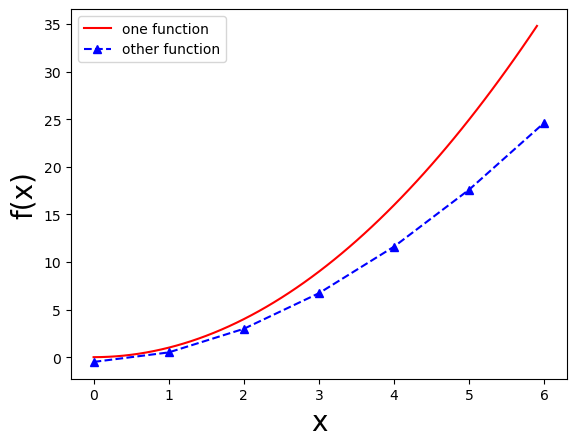

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

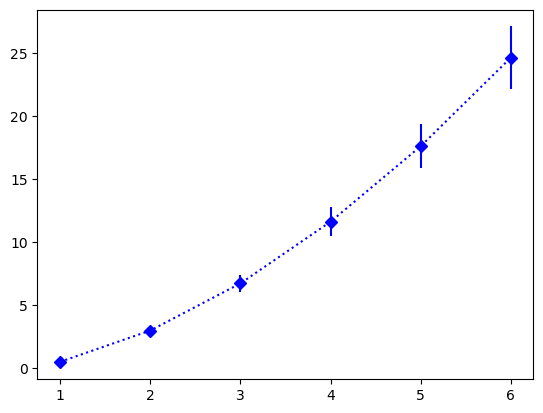

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])

<img src="figures/gezerlisTable1_3.png" width="67%">

<img src="figures/gezerlis_slicingArrays.png" width="67%">

### Visualizing Electric Fields 

The electric field anywhere given a set of $n$ point charges is given by
$$ \mathbf{E}(\mathbf{r}) = \sum_{i=0}^{n-1} kq_i \frac{\mathbf{r} - \mathbf{r}_i}{|\mathbf{r} - \mathbf{r}_i|^3} $$

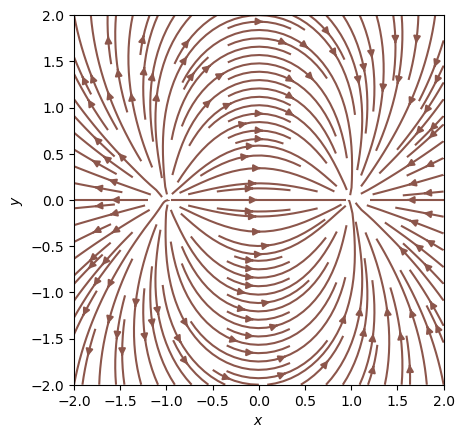

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from copy import deepcopy

def makefield(xs, ys):
    qtopos = {1: (-1,0), -1: (1,0)}
    n = len(xs)
    Exs = [[0. for k in range(n)] for j in range(n)]
    Eys = deepcopy(Exs)
    for j,x in enumerate(xs):
        for k,y in enumerate(ys):
            for q, pos in qtopos.items():
                posx, posy  = pos
                R = sqrt((x - posx)**2 + (y - posy)**2)
                Exs[k][j] += q*(x - posx)/R**3
                Eys[k][j] += q*(y - posy)/R**3
    return Exs, Eys

def plotfield(boxl,n):
    xs = [-boxl + i*2*boxl/(n-1) for i in range(n)]
    ys = xs[:]
    Exs, Eys = makefield(xs, ys)
    xs=np.array(xs); ys=np.array(ys)
    Exs=np.array(Exs); Eys=np.array(Eys)
    plt.streamplot(xs, ys, Exs, Eys, density=1.5, color='tab:brown')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.axis('square')
    plt.show()
    
plotfield(2., 50)

In [48]:
# sample plotting in notebook and putting saved image in another cell (see Report figure)

import matplotlib.pyplot as plt
import numpy as np

# sample grid and data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z1 = np.sin(np.sqrt(X**2 + Y**2))        

# create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# plot on first axs (left)
axs[0].imshow(Z1, cmap='viridis')
axs[0].set_title("Subtitle 1")
axs[0].axis('off')

# plot on the second axis (right)
axs[1].imshow(Z1, cmap='plasma')
axs[1].set_title("Subtitle 2")
axs[1].axis('off')

fig.suptitle("Super title")

# save image locally without rendering in the notebook
plt.savefig('figures/sample.png', bbox_inches='tight', dpi=150)
plt.close()